# Cuesta College Course Success: 2030 Projection Analysis

## Direct institutional comparison to the EMP target

For the EMP target itself, the cleanest comparison remains the **actual overall institutional series**, because that is the same metric the target is defined against.

Observed overall rates:
- 2020–21: 74.71%
- 2021–22: 74.78%
- 2022–23: 75.94%
- 2023–24: 76.61%
- 2024–25: 77.05%
- 2025–26: 79.06%

The EMP target is **87.05% by 2029–30**, or +10 percentage points from the 2024–25 baseline.


In [38]:
overall = pd.DataFrame({
    "start_year": [2020, 2021, 2022, 2023, 2024, 2025],
    "success_pct": [74.71, 74.78, 75.94, 76.61, 77.05, 79.06]
})

overall_years = np.arange(2020, 2030)

# Baseline-era linear model: data available through 2024–25
baseline_overall = overall[overall["start_year"] <= 2024]
coef_base, overall_linear_base = fit_linear(baseline_overall, overall_years)

# Updated linear model through 2025–26
coef_updated, overall_linear_updated = fit_linear(overall, overall_years)

# Updated bounded logit
_, overall_logit_updated = fit_logit(overall, overall_years)

# Ambitious policy scenario
ambitious = np.full(len(overall_years), np.nan)
m = overall_years >= 2025
ambitious[m] = 79.06 + 1.5 * (overall_years[m] - 2025)

# EMP trajectory
emp = np.full(len(overall_years), np.nan)
m2 = overall_years >= 2024
emp[m2] = 77.05 + 2.0 * (overall_years[m2] - 2024)

institutional_summary = pd.DataFrame({
    "Scenario": [
        "Linear through 2024–25",
        "Updated linear through 2025–26",
        "Updated bounded logit",
        "Ambitious +1.5 pts/year",
        "EMP target"
    ],
    "2029–30 (%)": [
        overall_linear_base[-1],
        overall_linear_updated[-1],
        overall_logit_updated[-1],
        ambitious[-1],
        emp[-1]
    ]
})

institutional_summary.round(2)


,Scenario,2029–30 (%)
0,Linear through 2024–25,80.37
1,Updated linear through 2025–26,81.79
2,Updated bounded logit,81.43
3,Ambitious +1.5 pts/year,85.06
4,EMP target,87.05


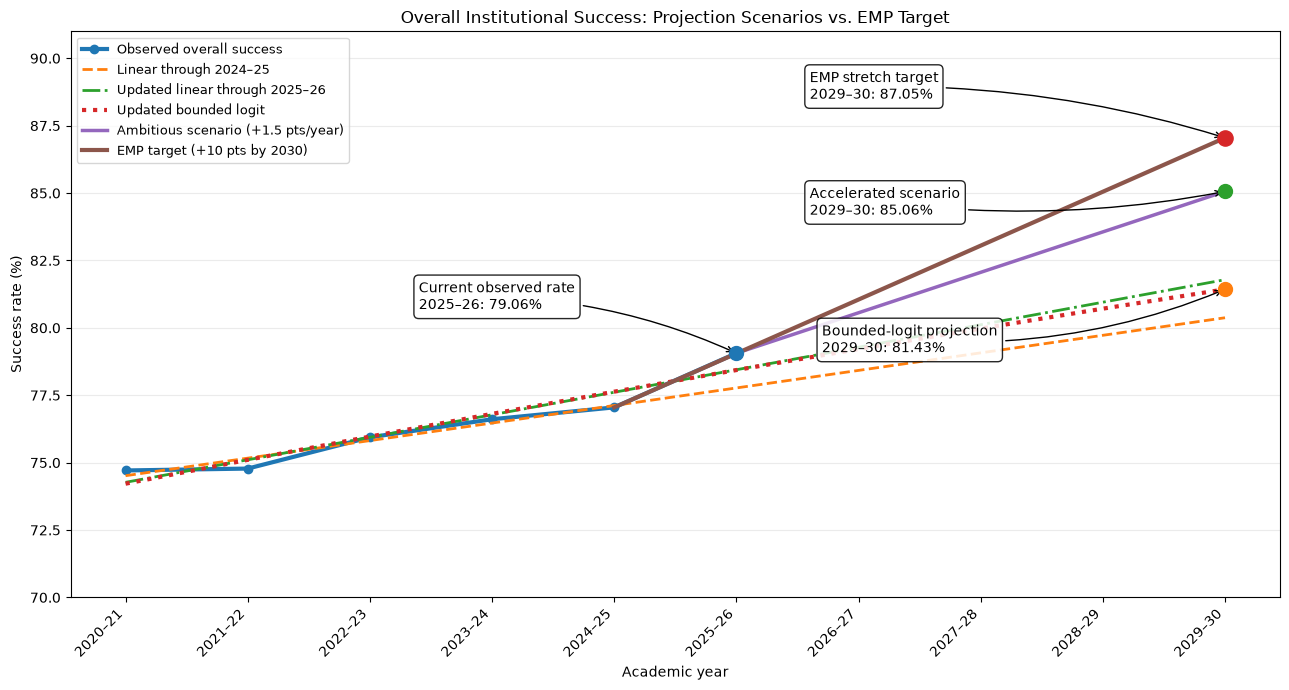

In [39]:
# ============================================================
# Section 6
# Overall institutional projections vs. EMP target
# with key endpoint annotations
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7))

# ------------------------------------------------------------
# Plot observed data
# ------------------------------------------------------------

ax.plot(
    overall["start_year"],
    overall["success_pct"],
    marker="o",
    linewidth=3,
    label="Observed overall success"
)

# ------------------------------------------------------------
# Plot projection methods
# ------------------------------------------------------------

ax.plot(
    overall_years,
    overall_linear_base,
    linestyle="--",
    linewidth=2,
    label="Linear through 2024–25"
)

ax.plot(
    overall_years,
    overall_linear_updated,
    linestyle="-.",
    linewidth=2,
    label="Updated linear through 2025–26"
)

ax.plot(
    overall_years,
    overall_logit_updated,
    linestyle=":",
    linewidth=3,
    label="Updated bounded logit"
)

ax.plot(
    overall_years,
    ambitious,
    linewidth=2.5,
    label="Ambitious scenario (+1.5 pts/year)"
)

ax.plot(
    overall_years,
    emp,
    linewidth=3,
    label="EMP target (+10 pts by 2030)"
)

# ============================================================
# Key values for annotations
# ============================================================

actual_2025 = overall.loc[
    overall["start_year"] == 2025,
    "success_pct"
].iloc[0]

logit_2030 = overall_logit_updated[
    overall_years == 2029
][0]

ambitious_2030 = ambitious[
    overall_years == 2029
][0]

emp_2030 = emp[
    overall_years == 2029
][0]


# ============================================================
# Highlight important endpoints
# ============================================================

ax.scatter(
    [2025],
    [actual_2025],
    s=100,
    zorder=6
)

ax.scatter(
    [2029],
    [logit_2030],
    s=100,
    zorder=6
)

ax.scatter(
    [2029],
    [ambitious_2030],
    s=100,
    zorder=6
)

ax.scatter(
    [2029],
    [emp_2030],
    s=120,
    zorder=6
)


# ============================================================
# Annotations
# ============================================================

# Current observed performance
ax.annotate(
    f"Current observed rate\n2025–26: {actual_2025:.2f}%",
    xy=(2025, actual_2025),
    xytext=(2022.4, 80.7),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.10"
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

# Bounded-logit statistical projection
ax.annotate(
    f"Bounded-logit projection\n2029–30: {logit_2030:.2f}%",
    xy=(2029, logit_2030),
    xytext=(2025.7, 79.1),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.12"
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

# Ambitious planning scenario
ax.annotate(
    f"Accelerated scenario\n2029–30: {ambitious_2030:.2f}%",
    xy=(2029, ambitious_2030),
    xytext=(2025.6, 84.2),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.08"
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

# EMP target
ax.annotate(
    f"EMP stretch target\n2029–30: {emp_2030:.2f}%",
    xy=(2029, emp_2030),
    xytext=(2025.6, 88.5),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.08"
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)


# ============================================================
# Formatting
# ============================================================

ax.set_title(
    "Overall Institutional Success: "
    "Projection Scenarios vs. EMP Target"
)

ax.set_xlabel("Academic year")
ax.set_ylabel("Success rate (%)")

ax.set_xticks(overall_years)

ax.set_xticklabels(
    [
        f"{y}–{str(y+1)[-2:]}"
        for y in overall_years
    ],
    rotation=45,
    ha="right"
)

# Slightly expanded range gives annotations breathing room
ax.set_ylim(70, 91)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()


## Key question: 
The institutional success rate is improving, but is that improvement broad-based? The following analyses disaggregate the trend by instructional modality and examine whether recent gains represent continuation of historical trends, a post-pandemic structural shift, or accelerated improvement concentrated in online courses.

# Cuesta College Course Success: Historical and 2030 Projection Analysis

This notebook uses the Tableau export **`Sheet 1_data.csv`** to analyze the longer historical record of course success by modality from **2008–09 through 2024–25**, while retaining the observed overall institutional series for direct comparison with the EMP Goal 1A target.

## Why separate the analyses?

The CSV contains:
- average course success rate by **Face to Face** and **Online** modality,
- retention rate,
- distinct CRN count.

It does **not** contain student enrollment counts or successful/attempted enrollment totals. Therefore, CRN counts should **not** be used as weights to reconstruct the overall college success rate.

Accordingly:

1. **Long historical modality models** are used to understand the underlying trajectory of Face-to-Face and Online success.
2. **Observed overall institutional rates** are modeled separately for the direct comparison with the proposed **87.05% 2029–30 EMP target**.

This avoids mixing two different aggregation methods.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load Tableau export.
# Keep Sheet 1_data.csv in the same folder as this notebook.
csv_path = Path("Sheet 1_data.csv")
df = pd.read_csv(csv_path)

# Clean / derive useful fields
df["start_year"] = df["Academic Year"].str.extract(r"(\d{4})").astype(int)
df["success_pct"] = df["Avg. Success Rate"] * 100
df["retention_pct"] = df["Avg.  Retention Rate"] * 100

df = df.sort_values(["Modality", "start_year"]).reset_index(drop=True)

print(df.shape)
df.head()


(34, 8)


,Modality,Academic Year,Avg. Retention Rate,Avg. Success Rate,Distinct count of CRN,start_year,success_pct,retention_pct
0,Face to Face,2008 - 2009,0.882571,0.724605,2526,2008,72.460472,88.257089
1,Face to Face,2009 - 2010,0.896655,0.746683,2547,2009,74.668343,89.665540
2,Face to Face,2010 - 2011,0.889524,0.749525,2476,2010,74.952502,88.952427
3,Face to Face,2011 - 2012,0.892603,0.749348,2448,2011,74.934841,89.260253
4,Face to Face,2012 - 2013,0.883174,0.736588,2216,2012,73.658796,88.317379


## 1. Visualize the full historical dataset

The first plot reproduces the long-term modality story in a form that makes the 2019–20 / 2020–21 disruption easy to see.


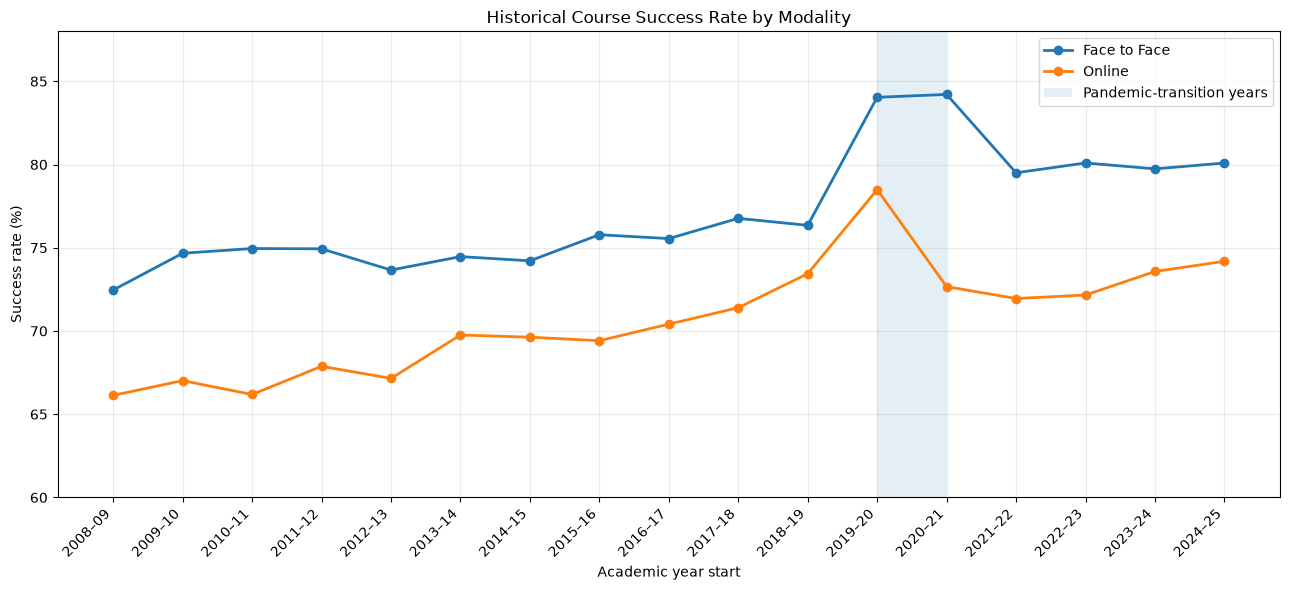

In [26]:
fig, ax = plt.subplots(figsize=(13, 6))

for modality, group in df.groupby("Modality"):
    ax.plot(
        group["start_year"],
        group["success_pct"],
        marker="o",
        linewidth=2,
        label=modality
    )

ax.axvspan(2019, 2020, alpha=0.12, label="Pandemic-transition years")
ax.set_title("Historical Course Success Rate by Modality")
ax.set_xlabel("Academic year start")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(range(df["start_year"].min(), df["start_year"].max() + 1))
ax.set_xticklabels(
    [f"{y}–{str(y+1)[-2:]}" for y in range(df["start_year"].min(), df["start_year"].max() + 1)],
    rotation=45, ha="right"
)
ax.set_ylim(60, 88)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## 2. Show the change in instructional composition

Distinct CRNs are **not enrollment counts**, but they are still useful descriptively. This plot shows how radically the instructional mix changed around the pandemic period, which helps explain why one simple regression through all years can be misleading.


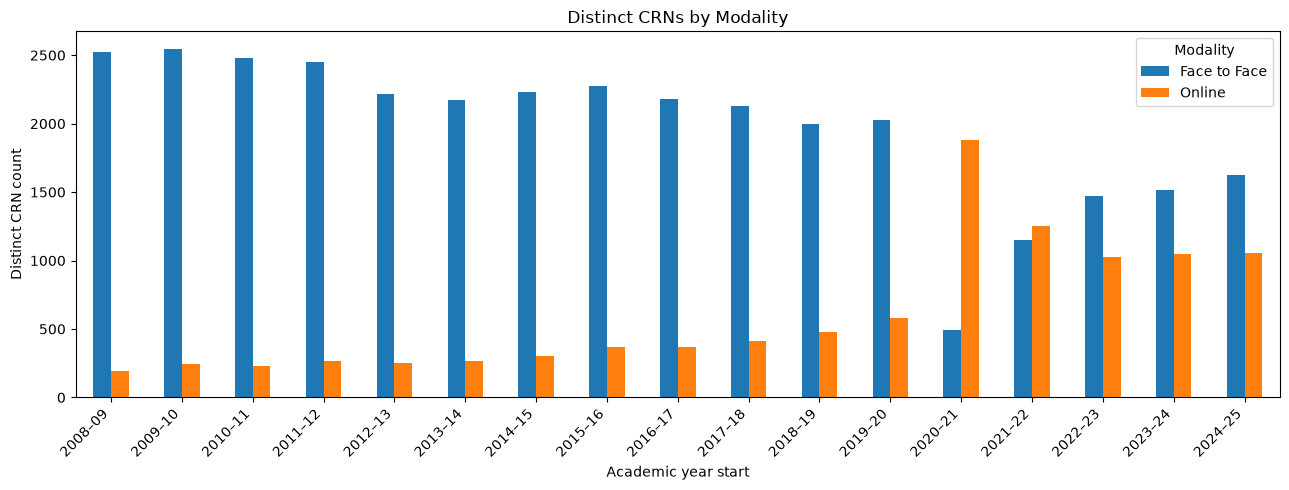

In [27]:
pivot_crn = df.pivot(index="start_year", columns="Modality", values="Distinct count of CRN")

fig, ax = plt.subplots(figsize=(13, 5))
pivot_crn.plot(kind="bar", ax=ax)
ax.set_title("Distinct CRNs by Modality")
ax.set_xlabel("Academic year start")
ax.set_ylabel("Distinct CRN count")
ax.set_xticklabels(
    [f"{y}–{str(y+1)[-2:]}" for y in pivot_crn.index],
    rotation=45, ha="right"
)
ax.legend(title="Modality")
plt.tight_layout()
plt.show()


## 3. Projection functions

We compare four model windows for each modality:

- **Naive full-history linear:** all 2008–09 through 2024–25 values.
- **Pre-COVID linear:** 2008–09 through 2018–19.
- **Post-COVID linear:** 2021–22 through 2024–25.
- **Bounded logit trend:** fits a line to log-odds rather than raw percentages.

The full-history model is included as a cautionary benchmark because the pandemic-period level shift strongly influences its slope.


In [28]:
def fit_linear(data, future_years):
    coef = np.polyfit(data["start_year"], data["success_pct"], 1)
    pred = np.polyval(coef, future_years)
    return coef, pred

def fit_logit(data, future_years):
    p = data["success_pct"].to_numpy() / 100
    logit = np.log(p / (1 - p))
    coef = np.polyfit(data["start_year"], logit, 1)
    z = np.polyval(coef, future_years)
    pred = 100 / (1 + np.exp(-z))
    return coef, pred

future_years = np.arange(2008, 2030)

results = []

for modality in ["Face to Face", "Online"]:
    g = df[df["Modality"] == modality].copy()

    windows = {
        "Full-history linear": g,
        "Pre-COVID linear": g[g["start_year"] <= 2018],
        "Post-COVID linear": g[g["start_year"] >= 2021],
    }

    for model_name, d in windows.items():
        coef, pred = fit_linear(d, future_years)
        results.append({
            "Modality": modality,
            "Model": model_name,
            "Slope_pp_per_year": coef[0],
            "Projected_2029_30": pred[future_years == 2029][0]
        })

    # Bounded logit using post-COVID values
    coef, pred = fit_logit(g[g["start_year"] >= 2021], future_years)
    results.append({
        "Modality": modality,
        "Model": "Post-COVID bounded logit",
        "Slope_pp_per_year": np.nan,
        "Projected_2029_30": pred[future_years == 2029][0]
    })

    # Bounded logit using the full historical record
    coef, pred = fit_logit(g, future_years)
    results.append({
        "Modality": modality,
        "Model": "Full-history bounded logit",
        "Slope_pp_per_year": np.nan,
        "Projected_2029_30": pred[future_years == 2029][0]
     })

projection_summary = pd.DataFrame(results)
projection_summary.round(2)


,Modality,Model,Slope_pp_per_year,Projected_2029_30
0,Face to Face,Full-history linear,0.55,84.36
1,Face to Face,Pre-COVID linear,0.29,79.52
2,Face to Face,Post-COVID linear,0.14,80.77
3,Face to Face,Post-COVID bounded logit,NaN,80.75
4,Face to Face,Full-history bounded logit,NaN,83.84
5,Online,Full-history linear,0.55,77.82
6,Online,Pre-COVID linear,0.66,79.46
7,Online,Post-COVID linear,0.81,78.25
8,Online,Post-COVID bounded logit,NaN,77.93
9,Online,Full-history bounded logit,NaN,77.39


## 4. Historical modality projections to 2029–30

These projections do **not** directly equal the overall institutional success rate. Instead, they show what the two major modalities would look like under different assumptions about which historical period best represents the future.


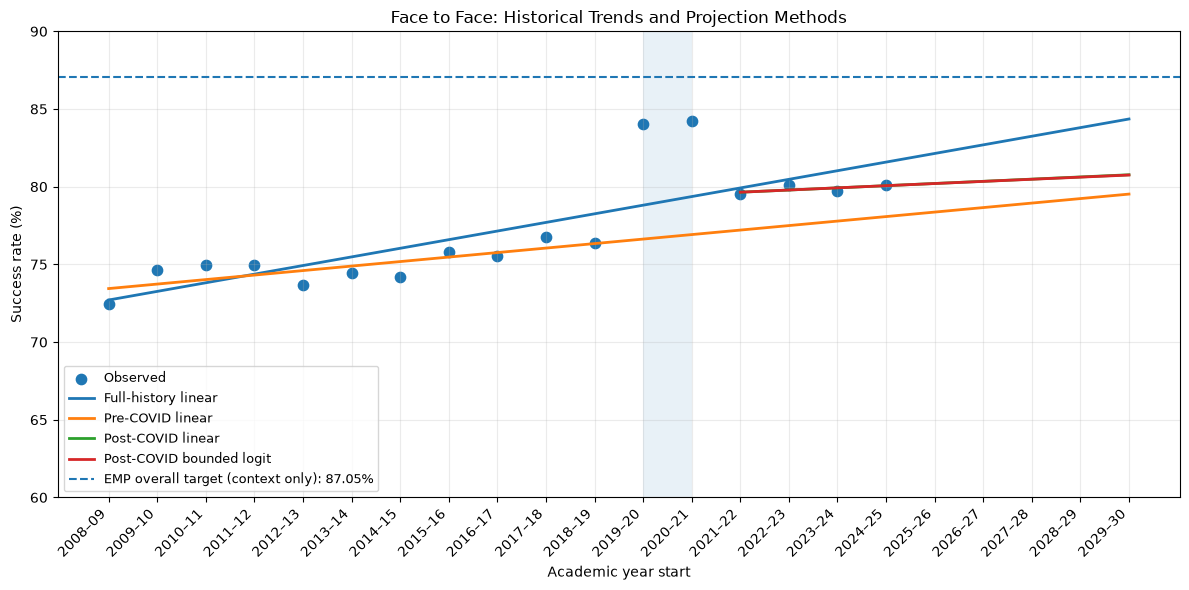

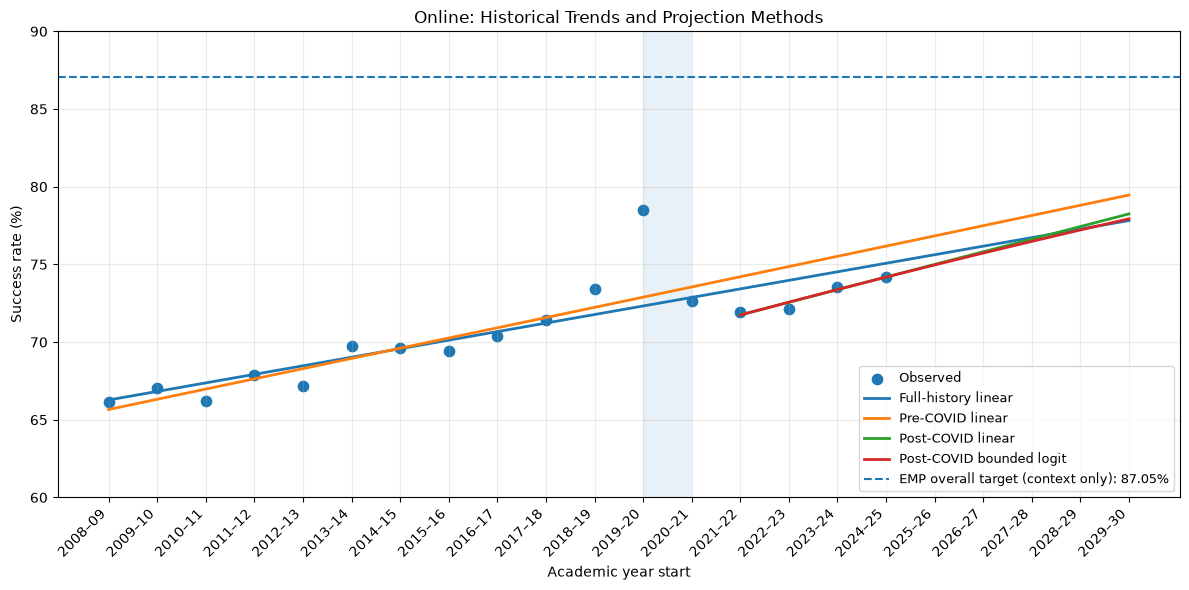

In [29]:
for modality in ["Face to Face", "Online"]:
    g = df[df["Modality"] == modality].copy()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(g["start_year"], g["success_pct"], s=55, label="Observed")

    model_specs = [
        ("Full-history linear", g, "linear"),
        ("Pre-COVID linear", g[g["start_year"] <= 2018], "linear"),
        ("Post-COVID linear", g[g["start_year"] >= 2021], "linear"),
        ("Post-COVID bounded logit", g[g["start_year"] >= 2021], "logit"),
    ]

    for label, d, kind in model_specs:
        if kind == "linear":
            _, pred = fit_linear(d, future_years)
        else:
            _, pred = fit_logit(d, future_years)

        # Plot only through the historical span used for display plus projection horizon
        mask = future_years >= d["start_year"].min()
        ax.plot(future_years[mask], pred[mask], linewidth=2, label=label)

    ax.axvspan(2019, 2020, alpha=0.10)
    ax.axhline(87.05, linestyle="--", linewidth=1.5,
               label="EMP overall target (context only): 87.05%")

    ax.set_title(f"{modality}: Historical Trends and Projection Methods")
    ax.set_xlabel("Academic year start")
    ax.set_ylabel("Success rate (%)")
    ax.set_xticks(range(2008, 2030))
    ax.set_xticklabels(
        [f"{y}–{str(y+1)[-2:]}" for y in range(2008, 2030)],
        rotation=45, ha="right"
    )
    ax.set_ylim(60, 90)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## Question: What does the full history bounded login preduction look like in both in person and online modalities?

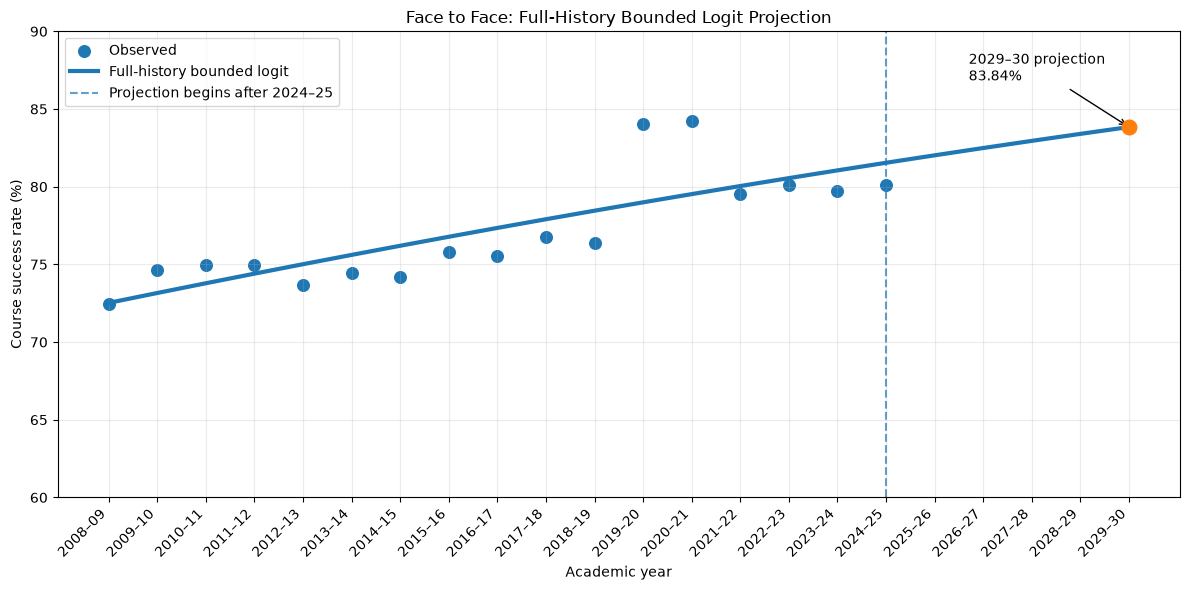

Face to Face projected 2029–30 success (full-history bounded logit): 83.84%


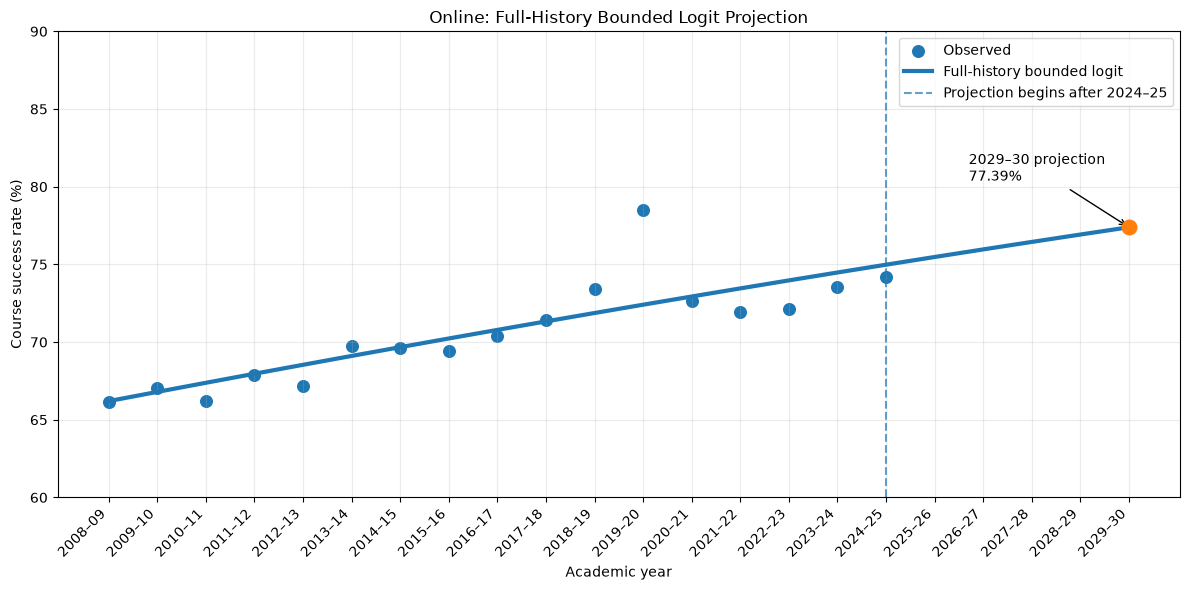

Online projected 2029–30 success (full-history bounded logit): 77.39%


In [36]:
# ============================================================
# Full-History Bounded Logit Projection by Modality
# Uses ALL available historical data: 2008–09 through 2024–25
# ============================================================

projection_years_full = np.arange(
    df["start_year"].min(),
    2030
)

for modality in ["Face to Face", "Online"]:

    # Select all historical observations for this modality
    g = (
        df[df["Modality"] == modality]
        .sort_values("start_year")
        .copy()
    )

    # Convert percentage to probability
    p = g["success_pct"].to_numpy() / 100

    # Convert probability to log-odds
    logit_p = np.log(p / (1 - p))

    # Fit a linear trend in log-odds space
    coef = np.polyfit(
        g["start_year"],
        logit_p,
        1
    )

    # Predict log-odds through 2029–30
    predicted_logit = np.polyval(
        coef,
        projection_years_full
    )

    # Transform predictions back to percentages
    predicted_pct = (
        100 / (1 + np.exp(-predicted_logit))
    )

    # Pull out the 2029–30 projection
    projected_2030 = predicted_pct[
        projection_years_full == 2029
    ][0]

    # --------------------
    # Plot
    # --------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    # Observed historical values
    ax.scatter(
        g["start_year"],
        g["success_pct"],
        s=70,
        label="Observed"
    )

    # Full-history bounded logit fit + projection
    ax.plot(
        projection_years_full,
        predicted_pct,
        linewidth=3,
        label="Full-history bounded logit"
    )

    # Mark where observed data end
    ax.axvline(
        2024,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label="Projection begins after 2024–25"
    )

    # Mark 2029–30 projection
    ax.scatter(
        [2029],
        [projected_2030],
        s=110,
        zorder=5
    )

    ax.annotate(
        f"2029–30 projection\n{projected_2030:.2f}%",
        xy=(2029, projected_2030),
        xytext=(2025.7, projected_2030 + 3),
        arrowprops=dict(arrowstyle="->")
    )

    ax.set_title(
        f"{modality}: Full-History Bounded Logit Projection"
    )

    ax.set_xlabel("Academic year")
    ax.set_ylabel("Course success rate (%)")

    ax.set_xticks(projection_years_full)
    ax.set_xticklabels(
        [
            f"{y}–{str(y+1)[-2:]}"
            for y in projection_years_full
        ],
        rotation=45,
        ha="right"
    )

    ax.set_ylim(60, 90)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(
        f"{modality} projected 2029–30 success "
        f"(full-history bounded logit): "
        f"{projected_2030:.2f}%"
    )

## 5. Compare the 2029–30 modality estimates

This figure makes the sensitivity to model choice explicit. A strong planning analysis should not hide that the answer changes depending on whether we treat the pandemic-era shift as part of the long-run trend or as a structural interruption.


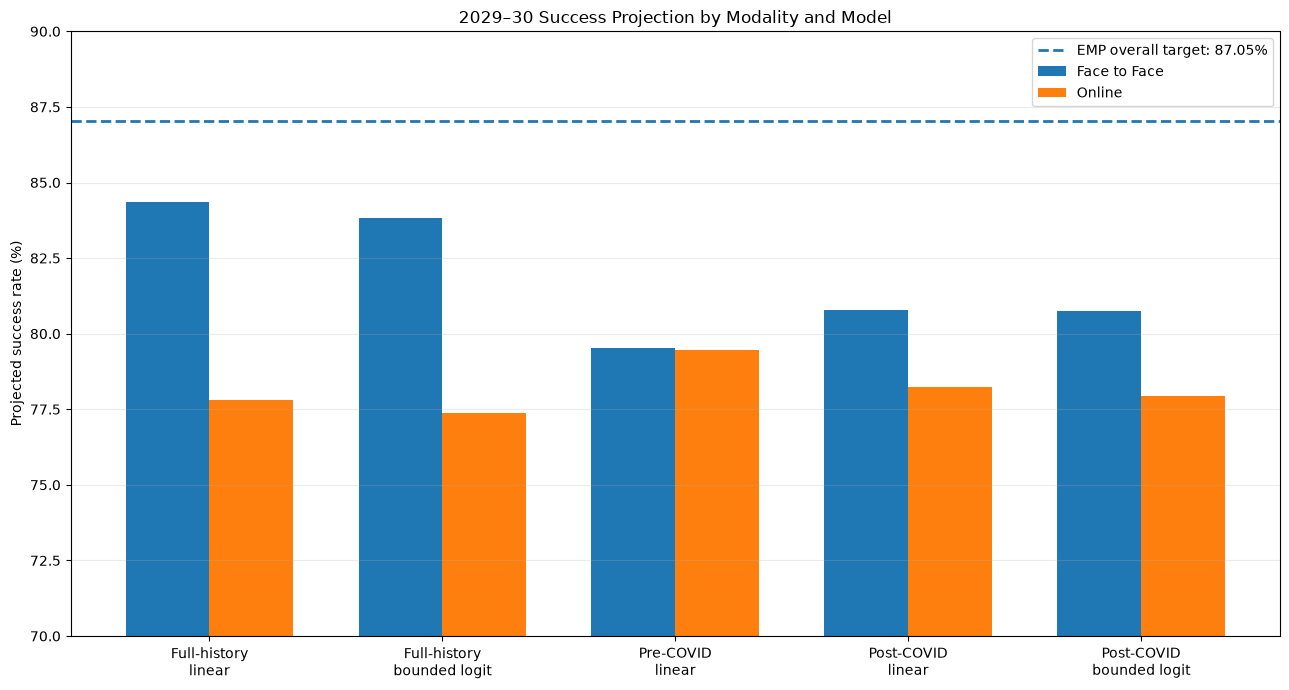

In [37]:
# ============================================================
# Section 5
# Compare 2029–30 projections across model choices
# ============================================================

plot_table = projection_summary.copy()

# Preserve a logical model order
model_order = [
    "Full-history linear",
    "Full-history bounded logit",
    "Pre-COVID linear",
    "Post-COVID linear",
    "Post-COVID bounded logit"
]

plot_table["Model"] = pd.Categorical(
    plot_table["Model"],
    categories=model_order,
    ordered=True
)

plot_table = plot_table.sort_values(["Model", "Modality"])

# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(13, 7))

modalities = list(plot_table["Modality"].unique())
models = model_order

x = np.arange(len(models))
width = 0.36

for i, modality in enumerate(modalities):

    vals = (
        plot_table[
            plot_table["Modality"] == modality
        ]
        .set_index("Model")
        .reindex(models)["Projected_2029_30"]
        .values
    )

    ax.bar(
        x + (i - 0.5) * width,
        vals,
        width=width,
        label=modality
    )

# EMP target for context
ax.axhline(
    87.05,
    linestyle="--",
    linewidth=2,
    label="EMP overall target: 87.05%"
)

ax.set_title(
    "2029–30 Success Projection by Modality and Model"
)

ax.set_ylabel(
    "Projected success rate (%)"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "Full-history\nlinear",
        "Full-history\nbounded logit",
        "Pre-COVID\nlinear",
        "Post-COVID\nlinear",
        "Post-COVID\nbounded logit"
    ]
)

ax.set_ylim(70, 90)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


## Interpretation

A defensible committee-level interpretation is:

- The **long historical modality data** show genuine long-term improvement, especially online, but also demonstrate that the pandemic period created a structural disruption that makes one simple all-years regression questionable.
- Recent **Face-to-Face** performance appears relatively flat near 80%, while **Online** performance has been increasing more quickly from a lower base.
- The direct institutional projections based on the actual overall metric remain in the **low-80% range** under straightforward statistical continuation.
- A deliberately accelerated planning scenario reaches approximately the **mid-80% range**.
- The EMP target of **87.05%** is therefore best characterized as a **stretch target**, not as the expected value produced by historical regression.
- Importantly, the observed **79.06% in 2025–26** is currently almost exactly on the EMP target trajectory, so the target cannot be dismissed as impossible; it simply requires the college to sustain an unusually rapid rate of improvement.

### Recommended next data request

For a statistically stronger institutional forecast, would need to request from Institutional Research:

- successful enrollments by year and modality,
- total graded/attempted enrollments by year and modality,
- ideally the same counts disaggregated by major student populations.

Those counts would allow a true **binomial logistic model** and a correctly weighted institutional projection rather than relying on modality averages or CRN counts.
